# 🎓 Smart Campus Behavior Analytics – UTS
### Analisis Pola Mobilitas Mahasiswa Kampus TUP
*Google Colab Ready | Semua data dari Google Drive*

In [1]:
# ============================================================
# CELL 1: Install & Import Library
# ============================================================

import os, re, io, math, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from scipy.signal import butter, filtfilt
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
# ============================================================
# CELL 2: Autentikasi Google Drive
# ============================================================
auth.authenticate_user()
drive_service = build('drive', 'v3', cache_discovery=False)
print("✅ Autentikasi Google Drive berhasil")


✅ Autentikasi Google Drive berhasil


In [3]:
# ============================================================
# CELL 3: Definisi Checkpoint & Konfigurasi
# ============================================================
CHECKPOINTS = {
    'A: DSP':              (-7.434592, 109.251123),
    'B: Parkir Luar DSP':  (-7.434922, 109.251139),
    'C: Rektorat':         (-7.434919, 109.251687),
    'D: Climbing':         (-7.434454, 109.251640),
    'E: Parkiran Terbuka': (-7.435077, 109.251961),
    'F: DC':               (-7.434873, 109.252311),
    'G: Iot':              (-7.43465597,  109.2523049),
    'H: TT':               (-7.434455, 109.252248),
}

# ── ID Folder Google Drive ──
FOLDER_ID = '1vOTHSxslSj5rnsJE3SuZp5rbTH5yf9hM'

# ── Toleransi pengambilan data ──
CP_RADIUS_M        = 20    # meter – radius zona checkpoint
STOP_MIN_SEC       = 2     # detik minimal berhenti di CP
START_TOL_SEC      = 60    # detik toleransi perbedaan waktu mulai antar user
MAX_PAUSE_COUNT    = 1     # DILONGGARKAN: maksimal pause yang diizinkan

# ── Kata kunci nama file yang HARUS di-skip ──
SKIP_KEYWORDS = [
    'mati 2 kali', 'mati dua kali', 'sempat mati',
    'beda hari',
    'kepencet', 'gepencet',
]

print("✅ Konfigurasi selesai")
print(f"   Radius CP      : {CP_RADIUS_M} meter")
print(f"   Min berhenti   : {STOP_MIN_SEC} detik")
print(f"   Toleransi mulai: {START_TOL_SEC} detik")
for name, (lat, lon) in CHECKPOINTS.items():
    print(f"   {name}: ({lat:.6f}, {lon:.6f})")

✅ Konfigurasi selesai
   Radius CP      : 20 meter
   Min berhenti   : 2 detik
   Toleransi mulai: 60 detik
   A: DSP: (-7.434592, 109.251123)
   B: Parkir Luar DSP: (-7.434922, 109.251139)
   C: Rektorat: (-7.434919, 109.251687)
   D: Climbing: (-7.434454, 109.251640)
   E: Parkiran Terbuka: (-7.435077, 109.251961)
   F: DC: (-7.434873, 109.252311)
   G: Iot: (-7.434656, 109.252305)
   H: TT: (-7.434455, 109.252248)


In [4]:
# ============================================================
# CELL 4: Fungsi Utilitas
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    """Jarak dua koordinat GPS dalam meter (Haversine formula)."""
    R = 6371000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi    = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def nearest_checkpoint(lat, lon, radius=CP_RADIUS_M):
    """Kembalikan nama CP terdekat jika dalam radius, else None."""
    best_name, best_dist = None, float('inf')
    for name, (clat, clon) in CHECKPOINTS.items():
        d = haversine(lat, lon, clat, clon)
        if d < best_dist:
            best_dist, best_name = d, name
    return (best_name, best_dist) if best_dist <= radius else (None, best_dist)

def butter_lowpass(data, cutoff=2.0, fs=50.0, order=4):
    """Low-pass Butterworth filter untuk noise akselerometer."""
    nyq = 0.5 * fs
    nc  = min(cutoff / nyq, 0.99)
    b, a = butter(order, nc, btype='low', analog=False)
    return filtfilt(b, a, data) if len(data) >= 15 else data

def sampling_rate(ts_series):
    """Estimasi sampling rate dari kolom timestamp."""
    diffs = np.diff(ts_series.values)
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return 50.0
    return min(1.0 / np.median(diffs), 200.0)

def short_uid(fname):
    """Buat user_id bersih dari nama file."""
    return re.sub(r'\.(xls|xlsx)$', '', fname, flags=re.IGNORECASE).strip()

print("✅ Fungsi utilitas siap")


✅ Fungsi utilitas siap


In [5]:
# ============================================================
# CELL 5: Parser File Phyphox (.xls / .xlsx)
# ============================================================
# Phyphox mengekspor ke Excel dengan sheet:
#   'Gyroscope'             – tidak dipakai
#   'Linear Accelerometer'  (.xlsx) / 'Linear Acceleration' (.xls)
#   'Location'
#   'Metadata Device'       – tidak dipakai
#   'Metadata Time'         – untuk deteksi start/pause

def load_phyphox(file_bytes, fname):
    """
    Parse file Phyphox.
    Return: (dict {'gps', 'accel', 'meta'}, error_str)
    """
    try:
        xls = pd.ExcelFile(io.BytesIO(file_bytes))
    except Exception as e:
        return None, f"Gagal buka file: {e}"

    sheet_map = {s.lower(): s for s in xls.sheet_names}
    result = {}

    # ── 1. GPS / Location ────────────────────────────────────
    loc_key = next((k for k in sheet_map if 'location' in k or 'lokasi' in k), None)
    if loc_key is None:
        return None, "Sheet Location tidak ditemukan"
    try:
        df_loc = pd.read_excel(xls, sheet_name=sheet_map[loc_key])
        df_loc.columns = [str(c).strip() for c in df_loc.columns]
        # Standardisasi nama kolom
        rename = {}
        for c in df_loc.columns:
            cl = c.lower()
            if 'time' in cl and 'time' not in rename.values():   rename[c] = 'time'
            elif 'lat'  in cl and 'lat'  not in rename.values(): rename[c] = 'lat'
            elif 'lon'  in cl and 'lon'  not in rename.values(): rename[c] = 'lon'
            elif 'veloc' in cl:                                   rename[c] = 'speed_gps'
            elif 'horiz' in cl and 'accur' in cl:                 rename[c] = 'h_acc'
        df_loc = df_loc.rename(columns=rename)
        for col in ['time','lat','lon']:
            df_loc[col] = pd.to_numeric(df_loc[col], errors='coerce')
        df_loc = df_loc.dropna(subset=['time','lat','lon']).reset_index(drop=True)
        # Buang baris dengan akurasi GPS buruk (>30m) jika tersedia
        if 'h_acc' in df_loc.columns:
            df_loc = df_loc[df_loc['h_acc'] <= 30].reset_index(drop=True)
        # Filter ke area kampus TUP
        df_loc = df_loc[
            df_loc['lat'].between(-7.437, -7.432) &
            df_loc['lon'].between(109.249, 109.255)
        ].reset_index(drop=True)
        if len(df_loc) < 10:
            return None, "Data GPS terlalu sedikit atau di luar area kampus"
        result['gps'] = df_loc
    except Exception as e:
        return None, f"Parse GPS gagal: {e}"

    # ── 2. Linear Accelerometer ──────────────────────────────
    # Nama sheet bisa 'linear accelerometer' (.xlsx) atau 'linear acceleration' (.xls)
    acc_key = next((k for k in sheet_map
                    if 'linear' in k and ('accel' in k or 'acc' in k)), None)
    if acc_key is None:
        # Fallback: cari sheet yang punya kolom x,y,z
        for k, v in sheet_map.items():
            if k in ('gyroscope', 'location', 'metadata device', 'metadata time'):
                continue
            try:
                df_t = pd.read_excel(xls, sheet_name=v, nrows=2)
                cols_low = [str(c).lower() for c in df_t.columns]
                if sum(1 for c in cols_low if any(ax in c for ax in ['x','y','z'])) >= 3:
                    acc_key = k
                    break
            except: continue
    if acc_key is None:
        return None, "Sheet Linear Accelerometer tidak ditemukan"
    try:
        df_acc = pd.read_excel(xls, sheet_name=sheet_map[acc_key])
        df_acc.columns = [str(c).strip() for c in df_acc.columns]
        rename = {}
        for c in df_acc.columns:
            cl = c.lower()
            if 'time' in cl and 'time' not in rename.values():            rename[c] = 'time'
            elif ('linear' in cl or 'x' == cl or cl.endswith('x (m/s^2)') or
                  'acceleration x' in cl or 'x (m' in cl) and 'ax' not in rename.values():
                rename[c] = 'ax'
            elif ('y' == cl or cl.endswith('y (m/s^2)') or
                  'acceleration y' in cl or 'y (m' in cl) and 'ay' not in rename.values():
                rename[c] = 'ay'
            elif ('z' == cl or cl.endswith('z (m/s^2)') or
                  'acceleration z' in cl or 'z (m' in cl) and 'az' not in rename.values():
                rename[c] = 'az'
        df_acc = df_acc.rename(columns=rename)
        # Jika masih belum ada ax/ay/az, assign by position (col 1,2,3 setelah time)
        if not {'ax','ay','az'}.issubset(df_acc.columns):
            cols = df_acc.columns.tolist()
            time_col = next((c for c in cols if 'time' in c.lower()), cols[0])
            others = [c for c in cols if c != time_col]
            if len(others) >= 3:
                df_acc = df_acc.rename(columns={
                    time_col: 'time',
                    others[0]: 'ax',
                    others[1]: 'ay',
                    others[2]: 'az',
                })
        for col in ['time','ax','ay','az']:
            df_acc[col] = pd.to_numeric(df_acc[col], errors='coerce')
        df_acc = df_acc.dropna(subset=['time','ax','ay','az']).reset_index(drop=True)
        if len(df_acc) < 20:
            return None, "Data accelerometer terlalu sedikit"
        result['accel'] = df_acc
    except Exception as e:
        return None, f"Parse Accelerometer gagal: {e}"

    # ── 3. Metadata Time (start/pause events) ────────────────
    meta_key = next((k for k in sheet_map if 'metadata time' in k or 'meta' in k and 'time' in k), None)
    if meta_key:
        try:
            df_meta = pd.read_excel(xls, sheet_name=sheet_map[meta_key])
            df_meta.columns = [str(c).strip().lower() for c in df_meta.columns]
            result['meta'] = df_meta
        except: pass

    return result, None

print("✅ Parser Phyphox siap")
print("   Sheet yang dibaca: Location, Linear Accelerometer/Acceleration, Metadata Time")


✅ Parser Phyphox siap
   Sheet yang dibaca: Location, Linear Accelerometer/Acceleration, Metadata Time


In [6]:
# ============================================================
# CELL 6: Data Cleaning & Preprocessing
# ============================================================
def clean_and_process(data_dict, user_id):
    """
    Pipeline cleaning:
    1. Normalisasi timestamp ke detik relatif
    2. Validasi start-pause dari Metadata Time
    3. Filter durasi perjalanan (8-60 menit)
    4. Butterworth low-pass filter accelerometer
    5. Magnitude & rolling average akselerasi
    6. Tandai setiap baris GPS dengan checkpoint terdekat
    7. Merge GPS + Accel by linear interpolation
    8. Estimasi kecepatan dari integrasi akselerasi
    9. Hitung jarak antar titik GPS
    """
    df_gps   = data_dict['gps'].copy()
    df_accel = data_dict['accel'].copy()

    # 1. Normalisasi waktu
    df_gps['t_rel']   = df_gps['time']   - df_gps['time'].min()
    df_accel['t_rel'] = df_accel['time'] - df_accel['time'].min()

    # 2. Validasi Metadata Time (deteksi start-pause berulang)
    if 'meta' in data_dict:
        df_m = data_dict['meta']
        if 'event' in df_m.columns:
            events = df_m['event'].astype(str).str.upper().tolist()
            pause_count = events.count('PAUSE')
            # Lebih dari MAX_PAUSE_COUNT kali PAUSE = anomali start-stop
            if pause_count > MAX_PAUSE_COUNT:
                return None, (f"Anomali: {pause_count} kali PAUSE terdeteksi "
                               f"(max {MAX_PAUSE_COUNT}). Data diambil tidak sekali jalan.")
    else:
        # Fallback: cek gap GPS > 90 detik
        gaps = df_gps['t_rel'].diff().dropna()
        n_big = (gaps > 90).sum()
        if n_big > 2:
            return None, f"Anomali: {n_big} gap GPS >90 detik (kemungkinan pause berulang)"

    if 'metadata' in data_dict:
        df_m = data_dict['metadata']
        # Cari baris yang mengandung kata 'pause' atau 'henti'
        pause_events = df_m[df_m.apply(lambda row: row.astype(str).str.contains('pause|henti', case=False).any(), axis=1)]

        # Toleransi: Misal maksimal 2 kali pause (start-pause-resume-pause-stop)
        # Jika lebih dari itu, kemungkinan data tidak kontinu
        if len(pause_events) > 1:
            return None, f"Anomali: Terdeteksi {len(pause_events)} kali pause manual di Metadata"
    else:
        # Fallback jika tidak ada metadata: perlonggar gap GPS jadi 120 detik
        gps_diffs = df_gps['t_rel'].diff().dropna()
        big_gaps = gps_diffs[gps_diffs > 90]
        if len(big_gaps) > 3:
            return None, f"Anomali: {len(big_gaps)} gap GPS sangat besar (>2 menit)"

    # 3. Durasi total (8–60 menit)
    dur = df_gps['t_rel'].max()
    if dur < 480:
        return None, f"Durasi terlalu pendek: {dur:.0f} detik (min 8 menit)"
    if dur > 3600:
        return None, f"Durasi terlalu panjang: {dur:.0f} detik (maks 60 menit)"

    # 4. Filter accelerometer
    fs = sampling_rate(df_accel['t_rel'])
    for ax in ['ax','ay','az']:
        try:
            df_accel[ax] = butter_lowpass(df_accel[ax].values, fs=fs)
        except: pass

    # 5. Magnitude & rolling average
    df_accel['acc_mag'] = np.sqrt(df_accel['ax']**2 + df_accel['ay']**2 + df_accel['az']**2)
    df_accel['acc_avg'] = df_accel['acc_mag'].rolling(10, min_periods=1).mean()

    # 6. Tandai checkpoint pada GPS
    df_gps['checkpoint'] = None
    df_gps['cp_dist_m']  = np.nan
    for idx, row in df_gps.iterrows():
        cp, dist = nearest_checkpoint(row['lat'], row['lon'])
        df_gps.at[idx, 'checkpoint'] = cp
        df_gps.at[idx, 'cp_dist_m']  = dist

    # 7. Merge GPS + Accel (DIPERBAIKI: Hapus duplikat index accelerometer)
    acc_idx    = df_accel.groupby('t_rel')['acc_avg'].mean()
    union_idx  = df_gps['t_rel'].drop_duplicates().values

    acc_interp = acc_idx.reindex(
        acc_idx.index.union(union_idx)
    ).interpolate(method='index').reindex(df_gps['t_rel'].values)

    df_merged = df_gps.copy()
    df_merged['acc_avg'] = acc_interp.values
    df_merged['acc_avg'] = df_merged['acc_avg'].fillna(df_merged['acc_avg'].median())

    # 8. Estimasi kecepatan (integrasi numerik dengan decay saat diam)
    df_merged = df_merged.sort_values('t_rel').reset_index(drop=True)
    dt_arr   = df_merged['t_rel'].diff().fillna(0).values
    acc_vals = df_merged['acc_avg'].values
    speed    = np.zeros(len(acc_vals))
    for i in range(1, len(speed)):
        a_net   = max(0.0, acc_vals[i] - 0.3)   # deadband threshold
        speed[i] = speed[i-1] + a_net * dt_arr[i]
        if acc_vals[i] < 0.5:                    # diam → decay
            speed[i] *= 0.7
        speed[i] = min(speed[i], 3.0)            # batas jalan kaki
    df_merged['speed_est'] = speed

    # 9. Jarak antar titik GPS
    lats, lons = df_merged['lat'].values, df_merged['lon'].values
    dists = [0.0] + [haversine(lats[i-1],lons[i-1],lats[i],lons[i])
                     for i in range(1, len(lats))]
    df_merged['dist_m']  = dists
    df_merged['user_id'] = user_id

    return df_merged, None

print("✅ Fungsi clean_and_process siap")


✅ Fungsi clean_and_process siap


In [7]:
# ============================================================
# CELL 7: Deteksi Transition Path (Anti-Duplikasi Checkpoint)
# ============================================================
# ──────────────────────────────────────────────────────────────
# LOGIKA ANTI-DUPLIKASI:
# Seseorang bisa melintas bolak-balik di tepi zona checkpoint,
# sehingga GPS masuk-keluar-masuk lagi ke zona yang SAMA.
# Kode ini memastikan setiap kunjungan ke checkpoint yang SAMA
# digabung menjadi SATU visit, asalkan tidak ada checkpoint LAIN
# yang dikunjungi di antaranya.
#
# Contoh raw:   [A, A, A, keluar, A, A, B, B, keluar, B, C]
# Hasil bersih: [A (merged), B (merged), C]
# ──────────────────────────────────────────────────────────────
def detect_transitions(df_user, user_id):
    """
    Kembalikan (df_visits, df_transitions).
    Setiap baris df_visits = 1 kunjungan unik di 1 checkpoint.
    Kunjungan berulang ke CP yang sama (tanpa CP lain di antara)
    DIGABUNG menjadi 1 baris.
    """
    df = df_user.sort_values('t_rel').reset_index(drop=True)

    # ── STEP 1: Buat sequence event (masuk CP / keluar CP) ──
    # Format: list of dict {cp, t_rel, lat, lon, speed_est, acc_avg}
    events = []
    # prev_cp = None
    for _, row in df.iterrows():
        # cp = row['checkpoint']
        # if cp != prev_cp:
            events.append({
                # 'cp':        cp,
                'cp':        row['checkpoint'],
                't_rel':     row['t_rel'],
                'lat':       row['lat'],
                'lon':       row['lon'],
                'speed_est': row['speed_est'],
                'acc_avg':   row['acc_avg'],
            })
            # prev_cp = cp

    # ── STEP 2: Buat segmen per CP (gabung jika CP sama berturut) ──
    # Algoritma: jalan melalui events, jika cp tidak None → tambah ke buffer.
    # Jika cp berbeda (bukan None) → tutup buffer lama, buka buffer baru.
    # Jika cp = None → tutup buffer aktif jika ada (user keluar zona).
    # Pada saat menutup, jika cp yang sama sudah ada di visits dan
    # CP terakhir sebelum None adalah cp yang sama → MERGE (update time_exit).

    visits = []   # list of dict per kunjungan final

    # Buffer untuk visit yang sedang aktif
    buf_cp     = None
    buf_enter  = None
    buf_rows   = []   # semua row GPS yang masuk zona ini

    for ev in events:
        cp = ev['cp']

        if cp is not None:
            if buf_cp is None:
                # Mulai kunjungan baru
                buf_cp    = cp
                buf_enter = ev['t_rel']
                buf_rows  = [ev]

            elif cp == buf_cp:
                # Masuk lagi ke CP yang sama (setelah sempat keluar sebentar)
                # Cek apakah di antara gap ada visit CP lain yang sudah tersimpan
                # Karena kita masih di buf_cp yang sama dan belum ada CP lain,
                # ini tetap dianggap 1 kunjungan → lanjutkan buffer
                buf_rows.append(ev)

            else:
                # CP berbeda → tutup kunjungan lama
                # _flush_visit(buf_cp, buf_enter, buf_rows, visits, user_id)
                # # Mulai kunjungan baru
                # buf_cp    = cp
                # buf_enter = ev['t_rel']
                # buf_rows  = [ev]

                # Pindah ke CP berbeda → tutup kunjungan lama
                if buf_rows:
                    _flush_visit(buf_cp, buf_enter, buf_rows, visits, user_id)
                # Mulai kunjungan baru
                buf_cp    = cp
                buf_enter = ev['t_rel']
                buf_rows  = [ev]

        else:
            # User keluar dari semua zona CP
            # Jangan langsung tutup – tunggu sampai kembali ke CP yang sama
            # atau ke CP berbeda. Kita tandai dengan None entry tapi buffer tetap.
            # Namun jika kunjungan kembali ke CP yang SAMA, kode di atas
            # akan masuk ke cabang `cp == buf_cp` dan memperpanjang buf.
            # Tidak perlu action di sini.
            pass

    # Tutup buffer terakhir
    if buf_cp is not None and buf_rows:
        _flush_visit(buf_cp, buf_enter, buf_rows, visits, user_id)

    df_visits = pd.DataFrame(visits)
    if df_visits.empty:
        return pd.DataFrame(), pd.DataFrame()

    # Buang visit yang durasinya < STOP_MIN_SEC
    df_visits = df_visits[df_visits['duration_s'] >= STOP_MIN_SEC].reset_index(drop=True)
    if df_visits.empty:
        return pd.DataFrame(), pd.DataFrame()

    # ── STEP 3: Hitung Transition Path ──
    transitions = []
    for i in range(len(df_visits) - 1):
        v1  = df_visits.iloc[i]
        v2  = df_visits.iloc[i+1]
        dist = haversine(v1['lat_mean'], v1['lon_mean'], v2['lat_mean'], v2['lon_mean'])
        tt   = v2['time_enter'] - v1['time_exit']
        spd  = dist / tt if tt > 0 else 0.0
        transitions.append({
            'user_id':         user_id,
            'from_cp':         v1['checkpoint'],
            'to_cp':           v2['checkpoint'],
            'transition_time': round(tt, 3),
            'distance_m':      round(dist, 3),
            'speed_est_ms':    round(spd, 4),
            'time_start':      v1['time_exit'],
            'time_end':        v2['time_enter'],
        })

    return df_visits, pd.DataFrame(transitions)


def _flush_visit(cp, t_enter, rows, visits_list, user_id):
    """Helper: hitung statistik kunjungan dan tambah ke list."""
    t_exit = rows[-1]['t_rel']
    dur    = t_exit - t_enter
    visits_list.append({
        'user_id':    user_id,
        'checkpoint': cp,
        'time_enter': t_enter,
        'time_exit':  t_exit,
        'duration_s': round(dur, 3),
        'lat_mean':   np.mean([r['lat']       for r in rows]),
        'lon_mean':   np.mean([r['lon']       for r in rows]),
        'speed_mean': np.mean([r['speed_est'] for r in rows]),
        'acc_mean':   np.mean([r['acc_avg']   for r in rows]),
    })

print("✅ Fungsi detect_transitions siap (duplikasi CP digabung)")


✅ Fungsi detect_transitions siap (duplikasi CP digabung)


In [8]:
# ============================================================
# CELL 8: Download & Proses Semua File dari Google Drive
# ============================================================

import time
from googleapiclient.errors import HttpError

def list_drive_files(folder_id):
    retries = 3  # Mencoba kembali maksimal 3 kali
    for i in range(retries):
        try:
            result = drive_service.files().list(
                q=f"'{folder_id}' in parents and trashed=false",
                fields="files(id,name,size,mimeType)",
                pageSize=100
            ).execute()
            return result.get('files', [])
        except Exception as e:
            if i < retries - 1:
                print(f"⚠️ Koneksi terputus, mencoba kembali ({i+1}/{retries})...")
                time.sleep(2) # Tunggu 2 detik sebelum mencoba lagi
                continue
            else:
                raise e

# def list_drive_files(folder_id):
#     result = drive_service.files().list(
#         q=f"'{folder_id}' in parents and trashed=false",
#         fields="files(id,name,size,mimeType)",
#         pageSize=100
#     ).execute()
#     return result.get('files', [])

def download_bytes(file_id):
    req    = drive_service.files().get_media(fileId=file_id)
    buf    = io.BytesIO()
    dl     = MediaIoBaseDownload(buf, req)
    done   = False
    while not done:
        _, done = dl.next_chunk()
    return buf.getvalue()

# ── Ambil daftar file ──
print("📂 Mengambil daftar file dari Google Drive...")
all_files = list_drive_files(FOLDER_ID)
print(f"   Total file ditemukan: {len(all_files)}\n")

all_merged      = []
all_visits      = []
all_transitions = []
skip_log        = []
error_log       = []

for f in all_files:
    fname = f['name']
    fid   = f['id']
    fsize = int(f.get('size', 0))

    # ── Filter ekstensi (hanya .xls dan .xlsx) ──
    if not re.search(r'\.(xls|xlsx)$', fname, re.IGNORECASE):
        skip_log.append({'file': fname, 'reason': 'Bukan file .xls/.xlsx'})
        continue

    # ── Cek kata kunci anomali di nama file ──
    fname_lower = fname.lower()
    skip_reason = next((kw for kw in SKIP_KEYWORDS if kw in fname_lower), None)
    if skip_reason:
        skip_log.append({'file': fname, 'reason': f'Keyword anomali: "{skip_reason}"'})
        print(f"  ⏭️  SKIP  : {fname}")
        print(f"            Alasan → keyword: '{skip_reason}'")
        continue

    # ── Cek ukuran file ──
    if fsize < 80_000:
        skip_log.append({'file': fname, 'reason': f'File terlalu kecil ({fsize:,} bytes)'})
        print(f"  ⏭️  SKIP  : {fname}")
        print(f"            Alasan → ukuran file {fsize:,} bytes (< 80 KB)")
        continue

    print(f"  📥 Proses : {fname[:55]:<55}", end='', flush=True)

    try:
        fbytes = download_bytes(fid)
        data, err = load_phyphox(fbytes, fname)
        if err:
            error_log.append({'file': fname, 'error': err})
            print(f" ❌ Load: {err}")
            continue

        uid = short_uid(fname)

        df_merged, err = clean_and_process(data, uid)
        if err:
            skip_log.append({'file': fname, 'reason': err})
            print(f" ⏭️  {err}")
            continue

        df_visits, df_trans = detect_transitions(df_merged, uid)
        if df_visits.empty:
            skip_log.append({'file': fname, 'reason': 'Tidak ada CP terdeteksi'})
            print(f" ⏭️  Tidak ada checkpoint terdeteksi")
            continue

        n_cp   = df_visits['checkpoint'].nunique()
        n_tran = len(df_trans)
        all_merged.append(df_merged)
        all_visits.append(df_visits)
        all_transitions.append(df_trans)
        print(f" ✅  {n_cp} CP unik | {n_tran} transisi")

    except Exception as e:
        error_log.append({'file': fname, 'error': str(e)})
        print(f" ❌ Error: {e}")

# ── Gabungkan ──
df_all_merged      = pd.concat(all_merged,      ignore_index=True) if all_merged      else pd.DataFrame()
df_all_visits      = pd.concat(all_visits,      ignore_index=True) if all_visits      else pd.DataFrame()
df_all_transitions = pd.concat(all_transitions, ignore_index=True) if all_transitions else pd.DataFrame()

print(f"\n{'='*65}")
print(f"  ✅ User valid    : {len(all_merged)}")
print(f"  ✅ Total visit CP: {len(df_all_visits)}")
print(f"  ✅ Total transisi: {len(df_all_transitions)}")
print(f"  ⏭️  Di-skip       : {len(skip_log)}")
print(f"  ❌ Error         : {len(error_log)}")
print(f"{'='*65}")

if skip_log:
    print("\n📋 File yang di-skip:")
    for s in skip_log:
        print(f"   - {s['file'][:55]}: {s['reason']}")
if error_log:
    print("\n❗ Error:")
    for e in error_log:
        print(f"   - {e['file'][:55]}: {e['error']}")


📂 Mengambil daftar file dari Google Drive...


   Total file ditemukan: 42

  📥 Proses : Jeremy Marcello Waani_2311110003.xls                    ✅  7 CP unik | 8 transisi
  📥 Proses : Chelsisdeo_2311110016.xls                               ⏭️  Anomali: 2 kali PAUSE terdeteksi (max 1). Data diambil tidak sekali jalan.
  📥 Proses : Brian Nugraha Wiyono_2311110052.xls                     ⏭️  Anomali: 3 kali PAUSE terdeteksi (max 1). Data diambil tidak sekali jalan.
  📥 Proses : NatashaEvaDwiNurdiyanti_2311110005.xlsx                 ✅  7 CP unik | 8 transisi
  📥 Proses : RosaNurAliana.xls                                       ✅  8 CP unik | 7 transisi
  📥 Proses : Muhammad Azka.xls                                       ✅  7 CP unik | 7 transisi
  📥 Proses : I Kadek Rio Adi Pranata Kusuma_103132400029.xls         ✅  6 CP unik | 8 transisi
  📥 Proses : Ferdinan_UTS.xls                                        ⏭️  Anomali: 3 kali PAUSE terdeteksi (max 1). Data diambil tidak sekali jalan.
  📥 Proses : Rifka a. S.xlsx                        

In [9]:
# ============================================================
# CELL 9: Summary Transition Path per User
# ============================================================
print("\n📊 SUMMARY: Transition Path per User")
print("="*90)

summary_rows = []
for uid in df_all_visits['user_id'].unique():
    v = df_all_visits[df_all_visits['user_id'] == uid]
    t = df_all_transitions[df_all_transitions['user_id'] == uid]

    cp_sequence  = v['checkpoint'].tolist()   # sudah bebas duplikasi berturut
    n_unique_cp  = v['checkpoint'].nunique()
    total_dist   = t['distance_m'].sum()  if not t.empty else 0
    avg_speed    = t['speed_est_ms'].mean() if not t.empty else 0

    summary_rows.append({
        'User ID':           uid,
        'Urutan CP':         ' → '.join([c.split(':')[0] for c in cp_sequence]),
        'Jumlah CP Unik':    n_unique_cp,
        'Total Jarak (m)':   round(total_dist, 1),
        'Avg Speed (m/s)':   round(avg_speed, 3),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)
df_summary.to_csv('/content/summary_transition_path.csv', index=False)
print("\n✅ Disimpan ke /content/summary_transition_path.csv")



📊 SUMMARY: Transition Path per User


,User ID,Urutan CP,Jumlah CP Unik,Total Jarak (m),Avg Speed (m/s)
0,Jeremy Marcello Waani_2311110003,D → A → B → C → E → C → E → H → F,7,312.3,8.814
1,NatashaEvaDwiNurdiyanti_2311110005,D → C → E → C → B → A → F → G → F,7,335.5,8.595
2,RosaNurAliana,D → A → B → C → E → F → G → H,8,255.6,9.418
3,Muhammad Azka,B → C → E → F → G → H → H → D,7,234.1,3.328
4,I Kadek Rio Adi Pranata Kusuma_103132400029,B → C → E → F → F → G → F → G → D,6,279.2,4.177
5,File UTS - Indy Aurellia,G → D → B → A → B → C → E → F,7,281.9,6.993
6,G_Vania Noverina_2311110031,G → H → F → E → C → B → D → C → B → C → E → C,7,423.0,3.784
7,Aprianti Ika Larasati_2311110023,F → E → C → B → C → D → H → F → G,7,338.5,4.262
8,Ahmad Fariz Gustav_2311110012,F → C → D → G → F → G,4,213.4,8.333
9,Joel Fransiskus Parulian Sitorus_2311110011,E → C → B → D → G → F → E → C,6,316.5,9.705



✅ Disimpan ke /content/summary_transition_path.csv


In [10]:
# ============================================================
# CELL 10: Tabel Output Format Tugas
# ============================================================
print("\n📋 OUTPUT MOBILITY EVENT (Format Tugas)")

output_rows = []
for uid in df_all_visits['user_id'].unique():
    v = df_all_visits[df_all_visits['user_id'] == uid].reset_index(drop=True)
    t = df_all_transitions[df_all_transitions['user_id'] == uid].reset_index(drop=True)

    for i, row in v.iterrows():
        cp_from = row['checkpoint']
        cp_to   = t.at[i, 'to_cp'] if i < len(t) else '-'
        output_rows.append({
            'Timestamp (s)':             round(row['time_enter'], 2),
            'ID':                        uid,
            'Avr Linear Accelerometer':  round(row['acc_mean'], 4),
            'Speed (m/s)':               round(row['speed_mean'], 4),
            'Checkpoint':                f"{cp_from} → {cp_to}",
            'Durasi di CP (s)':          round(row['duration_s'], 1),
        })

df_output = pd.DataFrame(output_rows)
display(df_output.head(40))
df_output.to_csv('/content/output_mobility_event.csv', index=False)
print(f"\n✅ Total baris : {len(df_output)}")
print("✅ Disimpan ke /content/output_mobility_event.csv")



📋 OUTPUT MOBILITY EVENT (Format Tugas)


,Timestamp (s),ID,Avr Linear Accelerometer,Speed (m/s),Checkpoint,Durasi di CP (s)
0,0.01,Jeremy Marcello Waani_2311110003,1.1788,2.3568,D: Climbing → A: DSP,28.4
1,121.45,Jeremy Marcello Waani_2311110003,0.9143,3.0000,A: DSP → B: Parkir Luar DSP,6.0
2,166.45,Jeremy Marcello Waani_2311110003,1.0407,2.2475,B: Parkir Luar DSP → C: Rektorat,49.0
3,234.45,Jeremy Marcello Waani_2311110003,1.5037,3.0000,C: Rektorat → E: Parkiran Terbuka,35.0
4,270.45,Jeremy Marcello Waani_2311110003,1.0361,2.0960,E: Parkiran Terbuka → C: Rektorat,49.0
5,320.45,Jeremy Marcello Waani_2311110003,0.9616,2.2116,C: Rektorat → E: Parkiran Terbuka,57.0
6,380.45,Jeremy Marcello Waani_2311110003,1.3886,3.0000,E: Parkiran Terbuka → H: TT,19.0
7,461.45,Jeremy Marcello Waani_2311110003,0.6570,1.4266,H: TT → F: DC,164.0
8,629.43,Jeremy Marcello Waani_2311110003,0.3502,1.0795,F: DC → -,16.0
9,0.00,NatashaEvaDwiNurdiyanti_2311110005,1.2187,2.6502,D: Climbing → C: Rektorat,25.0



✅ Total baris : 220
✅ Disimpan ke /content/output_mobility_event.csv


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



🔥 VISUALISASI 1: Heatmap Mobilitas


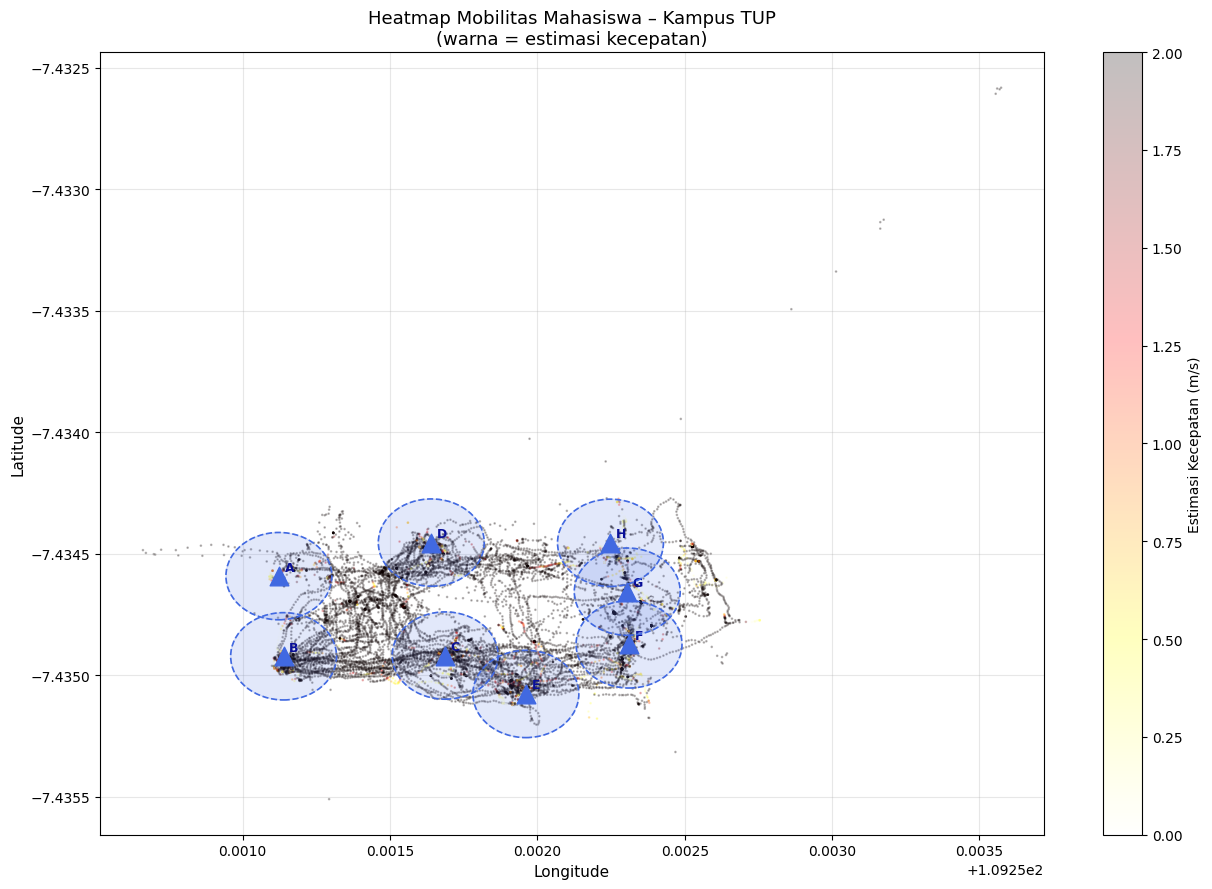

✅ Disimpan ke /content/heatmap_mobilitas.png


In [12]:
# ============================================================
# CELL 11: Visualisasi 1 – Heatmap GPS
# ============================================================
print("\n🔥 VISUALISASI 1: Heatmap Mobilitas")

if not df_all_merged.empty:
    fig, ax = plt.subplots(figsize=(13, 9))

    sc = ax.scatter(
        df_all_merged['lon'], df_all_merged['lat'],
        c=df_all_merged['speed_est'], cmap='hot_r',
        s=0.8, alpha=0.25, vmin=0, vmax=2.0
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Estimasi Kecepatan (m/s)', fontsize=10)

    for name, (clat, clon) in CHECKPOINTS.items():
        # Zona radius 20 m
        deg_r = CP_RADIUS_M / 111320
        circle = plt.Circle((clon, clat), deg_r,
                              color='royalblue', fill=True, alpha=0.15, zorder=4)
        ax.add_patch(circle)
        circle2 = plt.Circle((clon, clat), deg_r,
                               color='royalblue', fill=False,
                               linestyle='--', linewidth=1.2, zorder=5)
        ax.add_patch(circle2)
        ckey = name.split(':')[0].strip()
        ax.scatter(clon, clat, s=180, c='royalblue', zorder=6, marker='^')
        ax.annotate(ckey, (clon, clat),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=9, color='darkblue', fontweight='bold')

    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title('Heatmap Mobilitas Mahasiswa – Kampus TUP\n(warna = estimasi kecepatan)', fontsize=13)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/heatmap_mobilitas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Disimpan ke /content/heatmap_mobilitas.png")



🔗 VISUALISASI 2: Transition Graph (Nodes = CP, Edges = Movement)


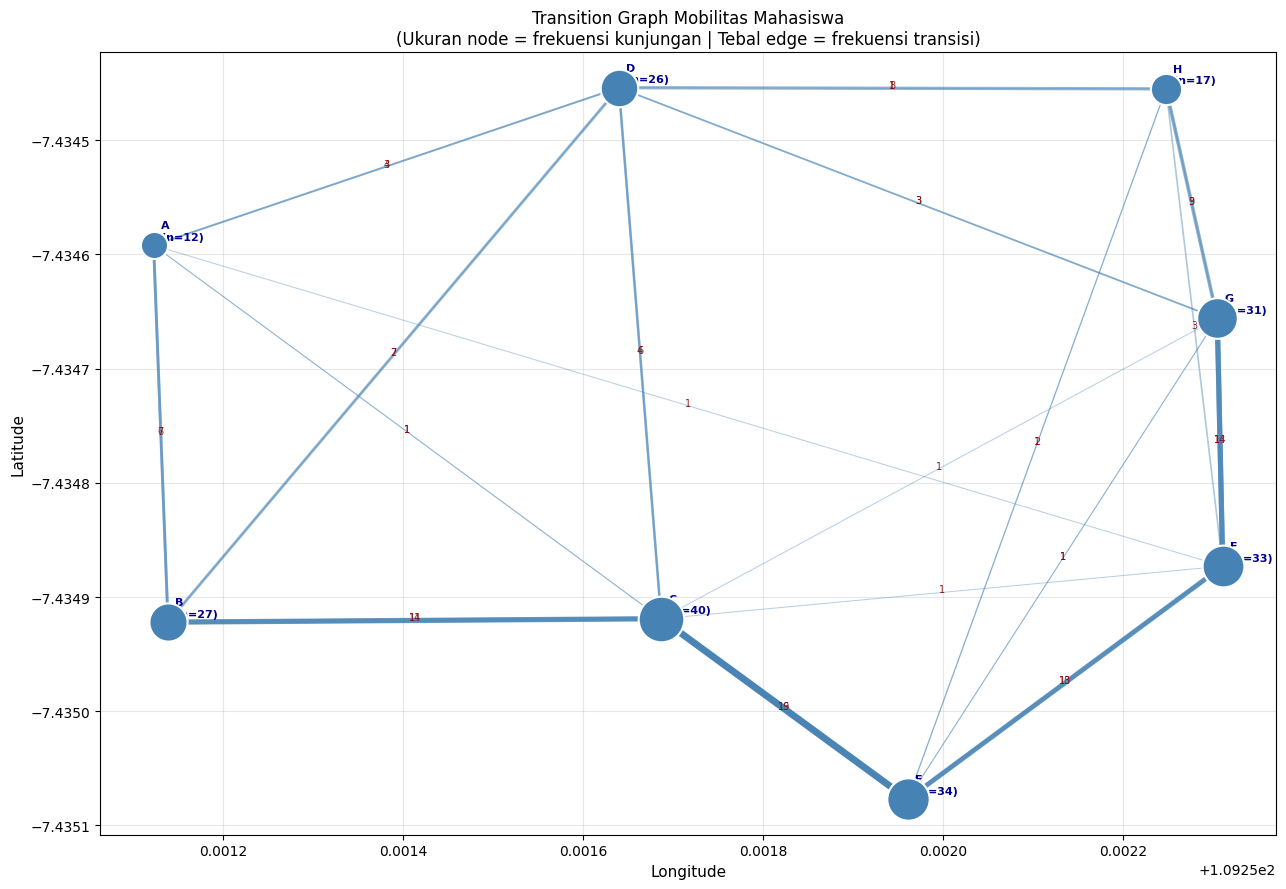

✅ Disimpan ke /content/transition_graph.png


In [13]:
# ============================================================
# CELL 12: Visualisasi 2 – Transition Graph
# ============================================================
print("\n🔗 VISUALISASI 2: Transition Graph (Nodes = CP, Edges = Movement)")

if not df_all_transitions.empty:
    edge_counts = (df_all_transitions
                   .groupby(['from_cp','to_cp']).size()
                   .reset_index(name='count'))

    fig, ax = plt.subplots(figsize=(13, 9))

    cp_pos = {k.split(':')[0].strip(): (v[1], v[0])
              for k, v in CHECKPOINTS.items()}
    max_cnt = edge_counts['count'].max()

    for _, row in edge_counts.iterrows():
        fr = row['from_cp'].split(':')[0].strip()
        to = row['to_cp'].split(':')[0].strip()
        if fr in cp_pos and to in cp_pos and fr != to:
            x1,y1 = cp_pos[fr]
            x2,y2 = cp_pos[to]
            lw    = 0.5 + 4.5 * (row['count'] / max_cnt)
            alpha = 0.35 + 0.55 * (row['count'] / max_cnt)
            ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                        arrowprops=dict(arrowstyle='->', color='steelblue',
                                        lw=lw, alpha=alpha))
            mx, my = (x1+x2)/2, (y1+y2)/2
            ax.text(mx, my, str(row['count']), fontsize=7,
                    ha='center', color='darkred', alpha=0.9)

    node_freq = df_all_visits.groupby('checkpoint').size()
    for cp_name, (clat, clon) in CHECKPOINTS.items():
        ckey = cp_name.split(':')[0].strip()
        freq = node_freq.get(cp_name, 1)
        sz   = 80 + freq * 25
        ax.scatter(clon, clat, s=sz, c='steelblue', zorder=6,
                   edgecolors='white', linewidth=1.5)
        ax.annotate(f"{ckey}\n(n={freq})", (clon, clat),
                    textcoords='offset points', xytext=(5,4),
                    fontsize=8, fontweight='bold', color='darkblue')

    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title('Transition Graph Mobilitas Mahasiswa\n'
                 '(Ukuran node = frekuensi kunjungan | Tebal edge = frekuensi transisi)',
                 fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/transition_graph.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Disimpan ke /content/transition_graph.png")


In [14]:
# ============================================================
# CELL 13: Visualisasi 3 – Sankey Diagram
# ============================================================
print("\n🌊 VISUALISASI 3: Sankey Diagram Movement Antar Checkpoint")

if not df_all_transitions.empty:
    all_cps  = list(CHECKPOINTS.keys())
    cp_short = [c.split(':')[0].strip() for c in all_cps]
    node_idx = {c: i for i, c in enumerate(all_cps)}

    edge_agg = (df_all_transitions
                .groupby(['from_cp','to_cp']).size()
                .reset_index(name='value'))
    edge_agg = edge_agg[
        edge_agg['from_cp'].isin(all_cps) &
        edge_agg['to_cp'].isin(all_cps) &
        (edge_agg['from_cp'] != edge_agg['to_cp'])
    ]

    src = [node_idx[r] for r in edge_agg['from_cp']]
    tgt = [node_idx[r] for r in edge_agg['to_cp']]
    val = edge_agg['value'].tolist()

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20, thickness=20,
            line=dict(color='black', width=0.5),
            label=cp_short,
            color=px.colors.qualitative.Pastel[:len(all_cps)]
        ),
        link=dict(source=src, target=tgt, value=val,
                  color='rgba(100,150,200,0.4)')
    ))
    fig.update_layout(
        title_text='Sankey Diagram: Pola Perpindahan Antar Checkpoint',
        font_size=12, height=520
    )
    fig.write_html('/content/sankey_diagram.html')
    fig.show()
    print("✅ Disimpan ke /content/sankey_diagram.html")



🌊 VISUALISASI 3: Sankey Diagram Movement Antar Checkpoint


✅ Disimpan ke /content/sankey_diagram.html


In [15]:
# ============================================================
# CELL 14: Visualisasi 4 – Floor Plan Route (Plotly Scattermap)
# ============================================================
print("\n🗺️  VISUALISASI 4: Floor Plan Route Animation (Plotly)")

if not df_all_merged.empty:
    users_sample = df_all_merged['user_id'].unique()[:8]
    colors_user  = px.colors.qualitative.Set2

    fig = go.Figure()
    for idx, uid in enumerate(users_sample):
        df_u = df_all_merged[df_all_merged['user_id'] == uid].sort_values('t_rel')
        uid_s = uid[:22] + '..' if len(uid) > 22 else uid
        fig.add_trace(go.Scatter(
            x=df_u['lon'], y=df_u['lat'],
            mode='lines',
            name=uid_s,
            line=dict(width=1.5, color=colors_user[idx % len(colors_user)]),
            opacity=0.7
        ))

    # Plot CP
    for name, (clat, clon) in CHECKPOINTS.items():
        ckey = name.split(':')[0].strip()
        fig.add_trace(go.Scatter(
            x=[clon], y=[clat],
            mode='markers+text', text=[ckey],
            textposition='top right',
            marker=dict(size=13, color='red', symbol='star'),
            name=ckey, showlegend=False
        ))

    fig.update_layout(
        title='Floor Plan Route – Jalur Mobilitas Mahasiswa Kampus TUP',
        xaxis_title='Longitude', yaxis_title='Latitude',
        xaxis=dict(scaleanchor='y', scaleratio=1),
        height=600, template='plotly_white'
    )
    fig.write_html('/content/floor_plan_route.html')
    fig.show()
    print("✅ Disimpan ke /content/floor_plan_route.html")



🗺️  VISUALISASI 4: Floor Plan Route Animation (Plotly)


✅ Disimpan ke /content/floor_plan_route.html



🗺️  VISUALISASI 5: Spatial Trajectory Map – Semua User
   24 user → 4 batch


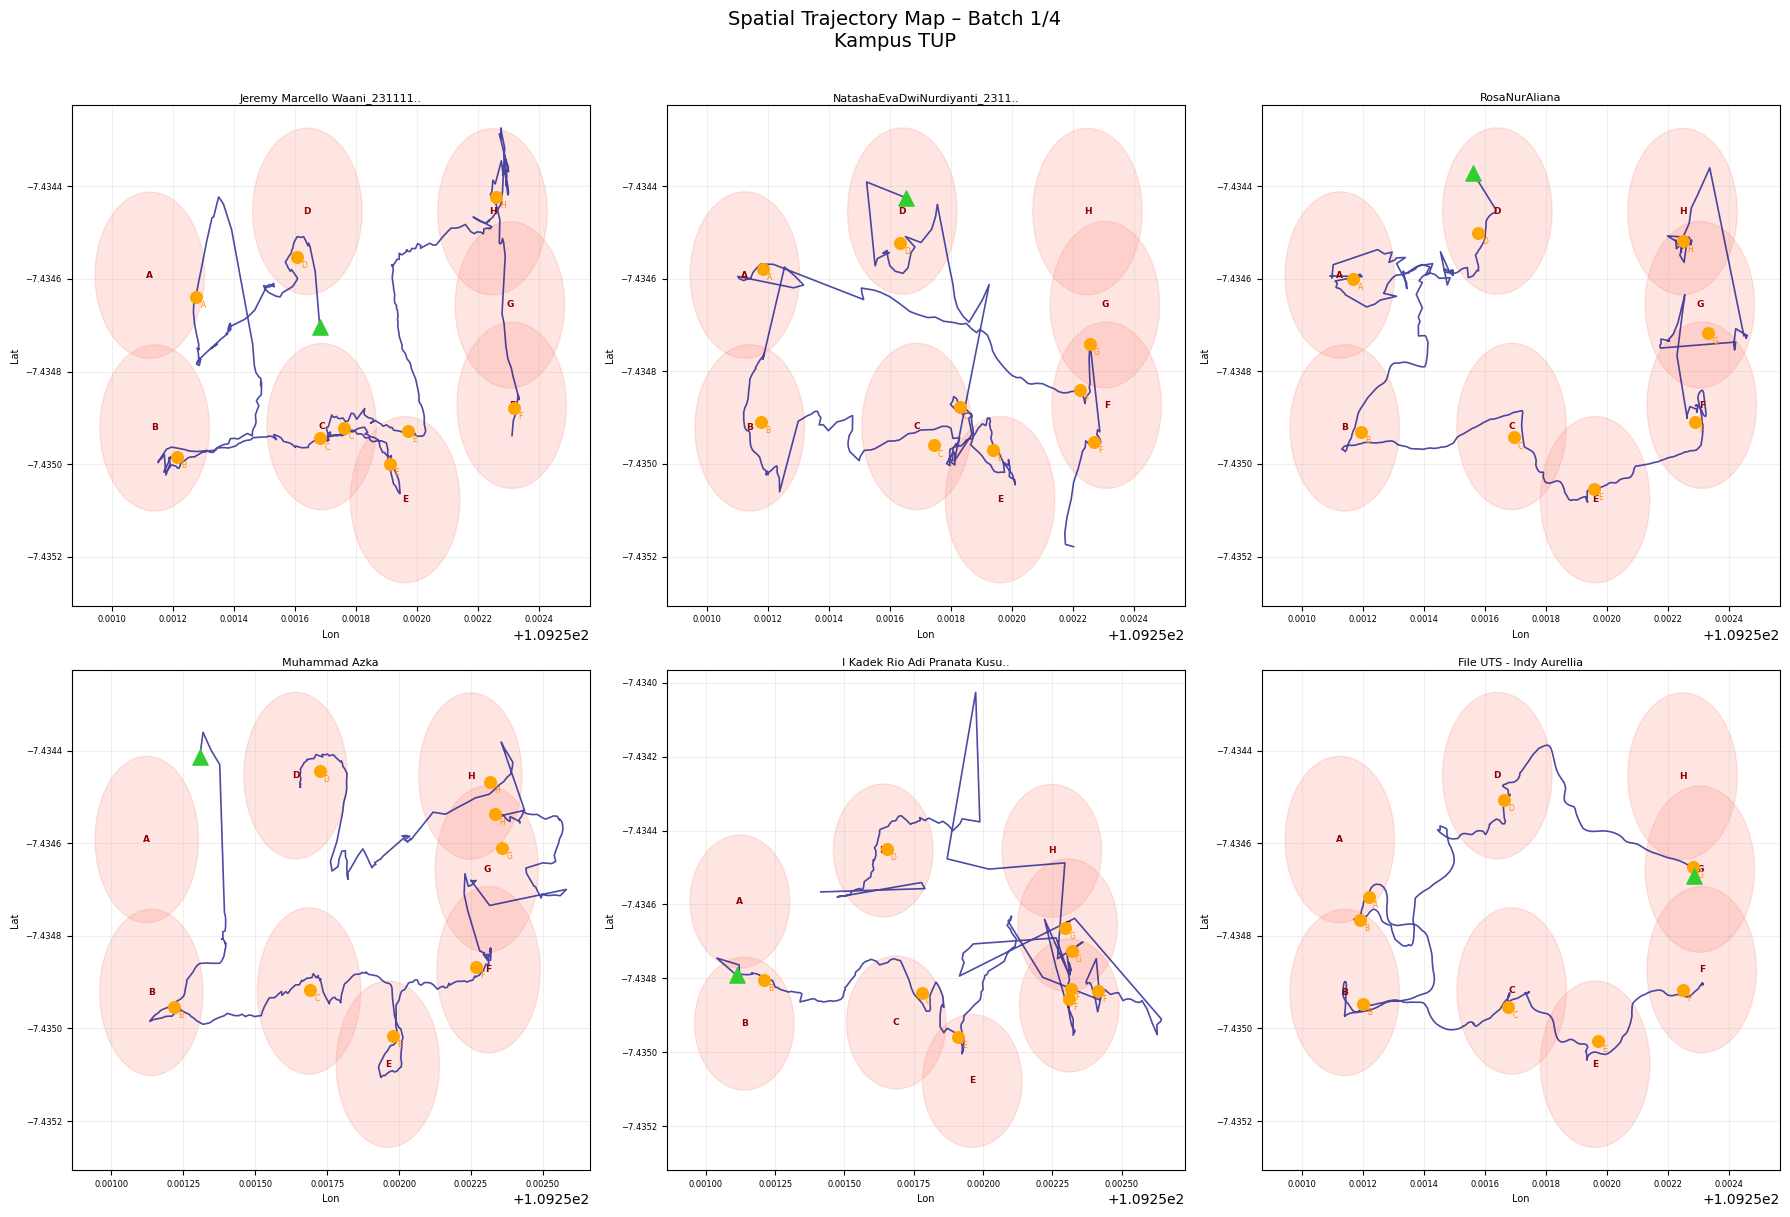

   ✅ Batch 1 disimpan ke /content/spatial_trajectory_batch_1.png


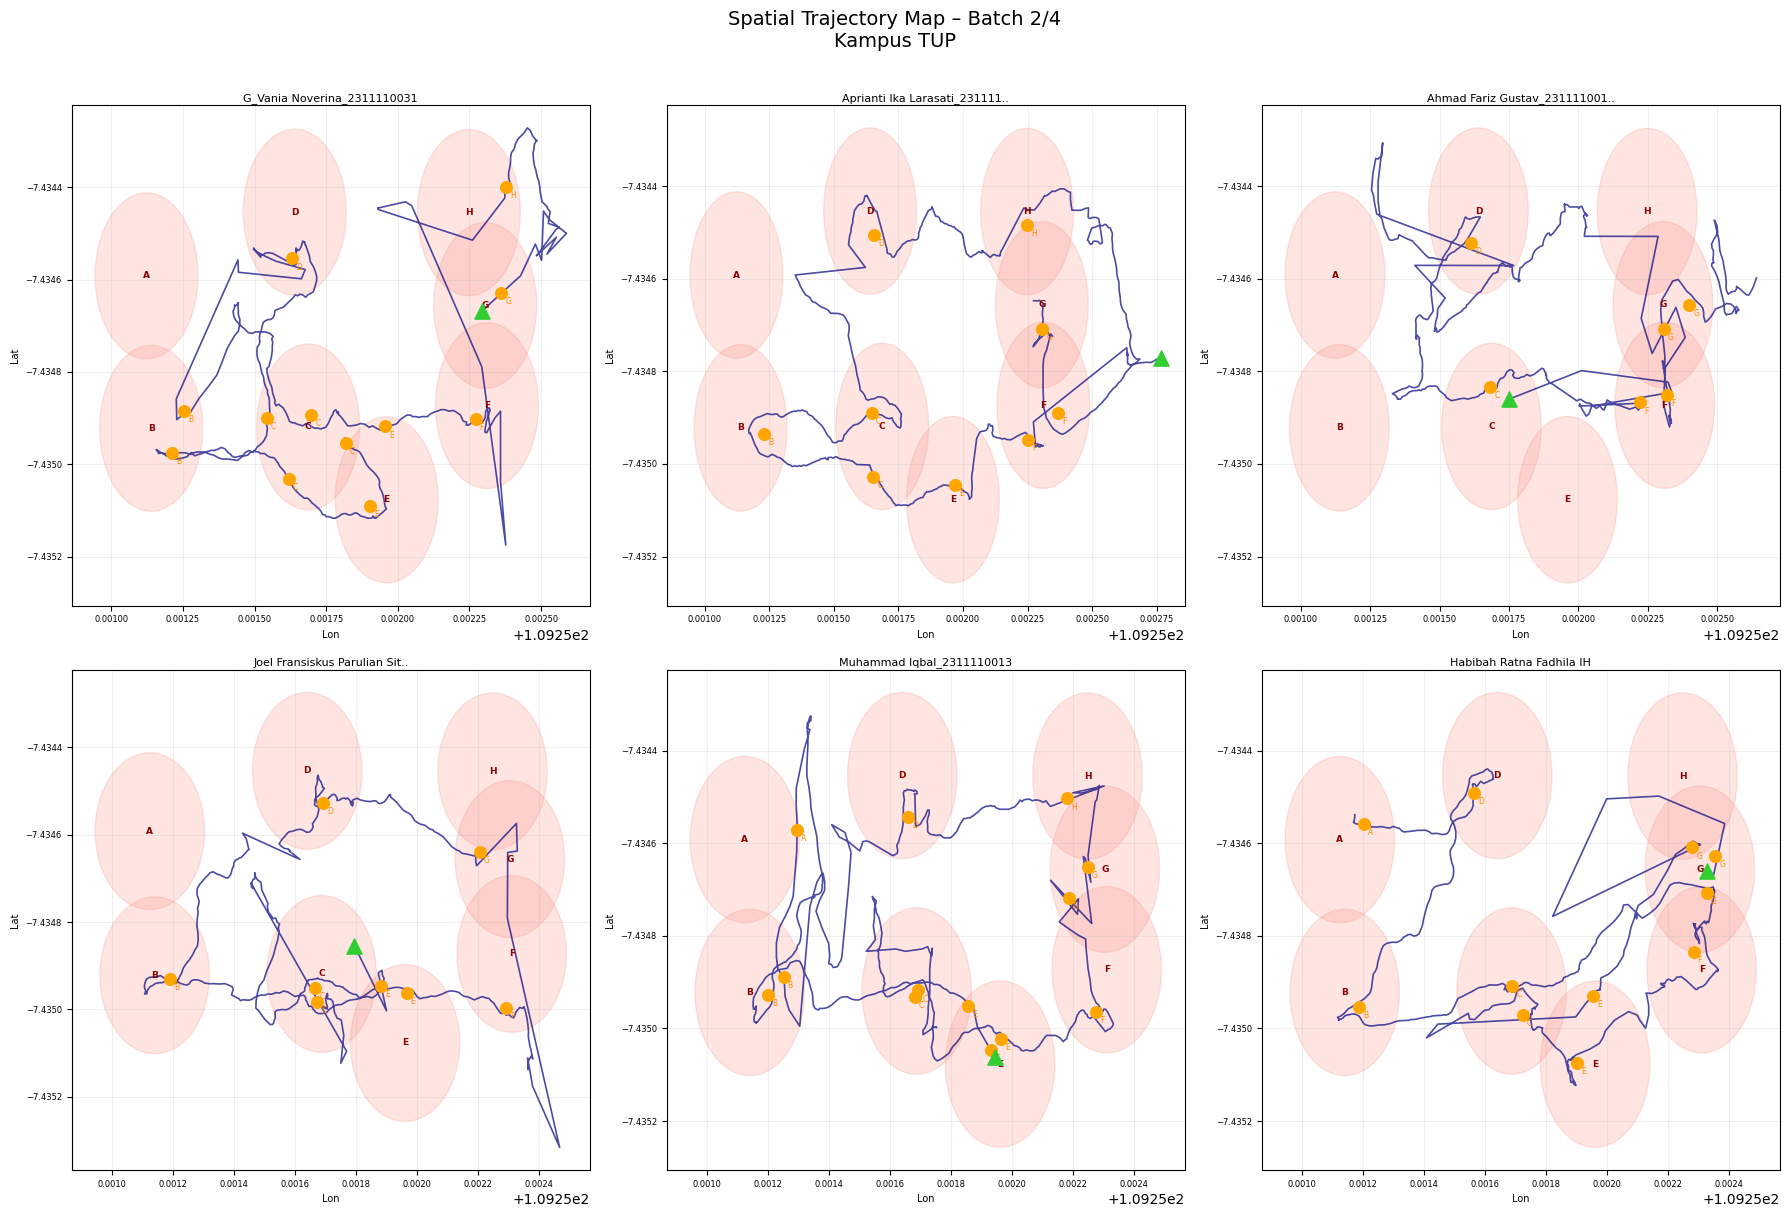

   ✅ Batch 2 disimpan ke /content/spatial_trajectory_batch_2.png


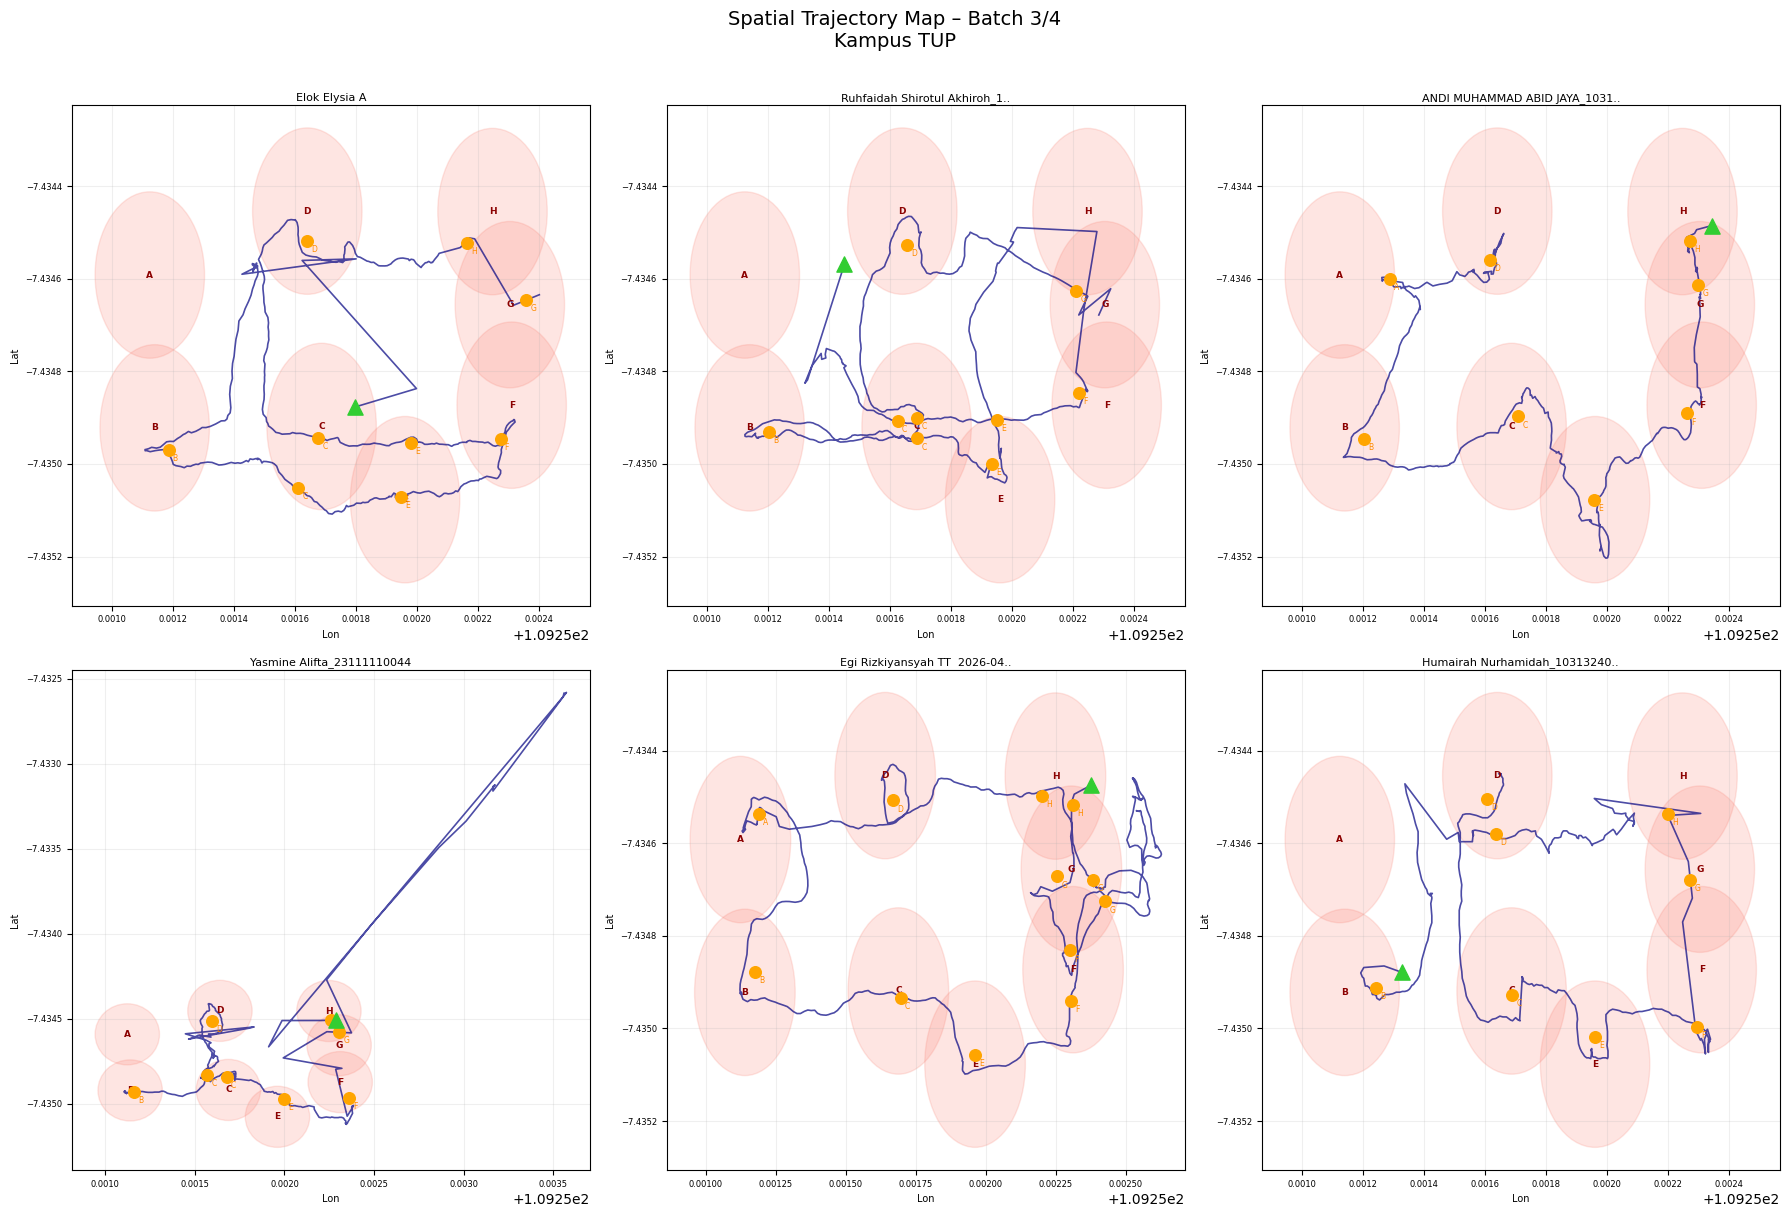

   ✅ Batch 3 disimpan ke /content/spatial_trajectory_batch_3.png


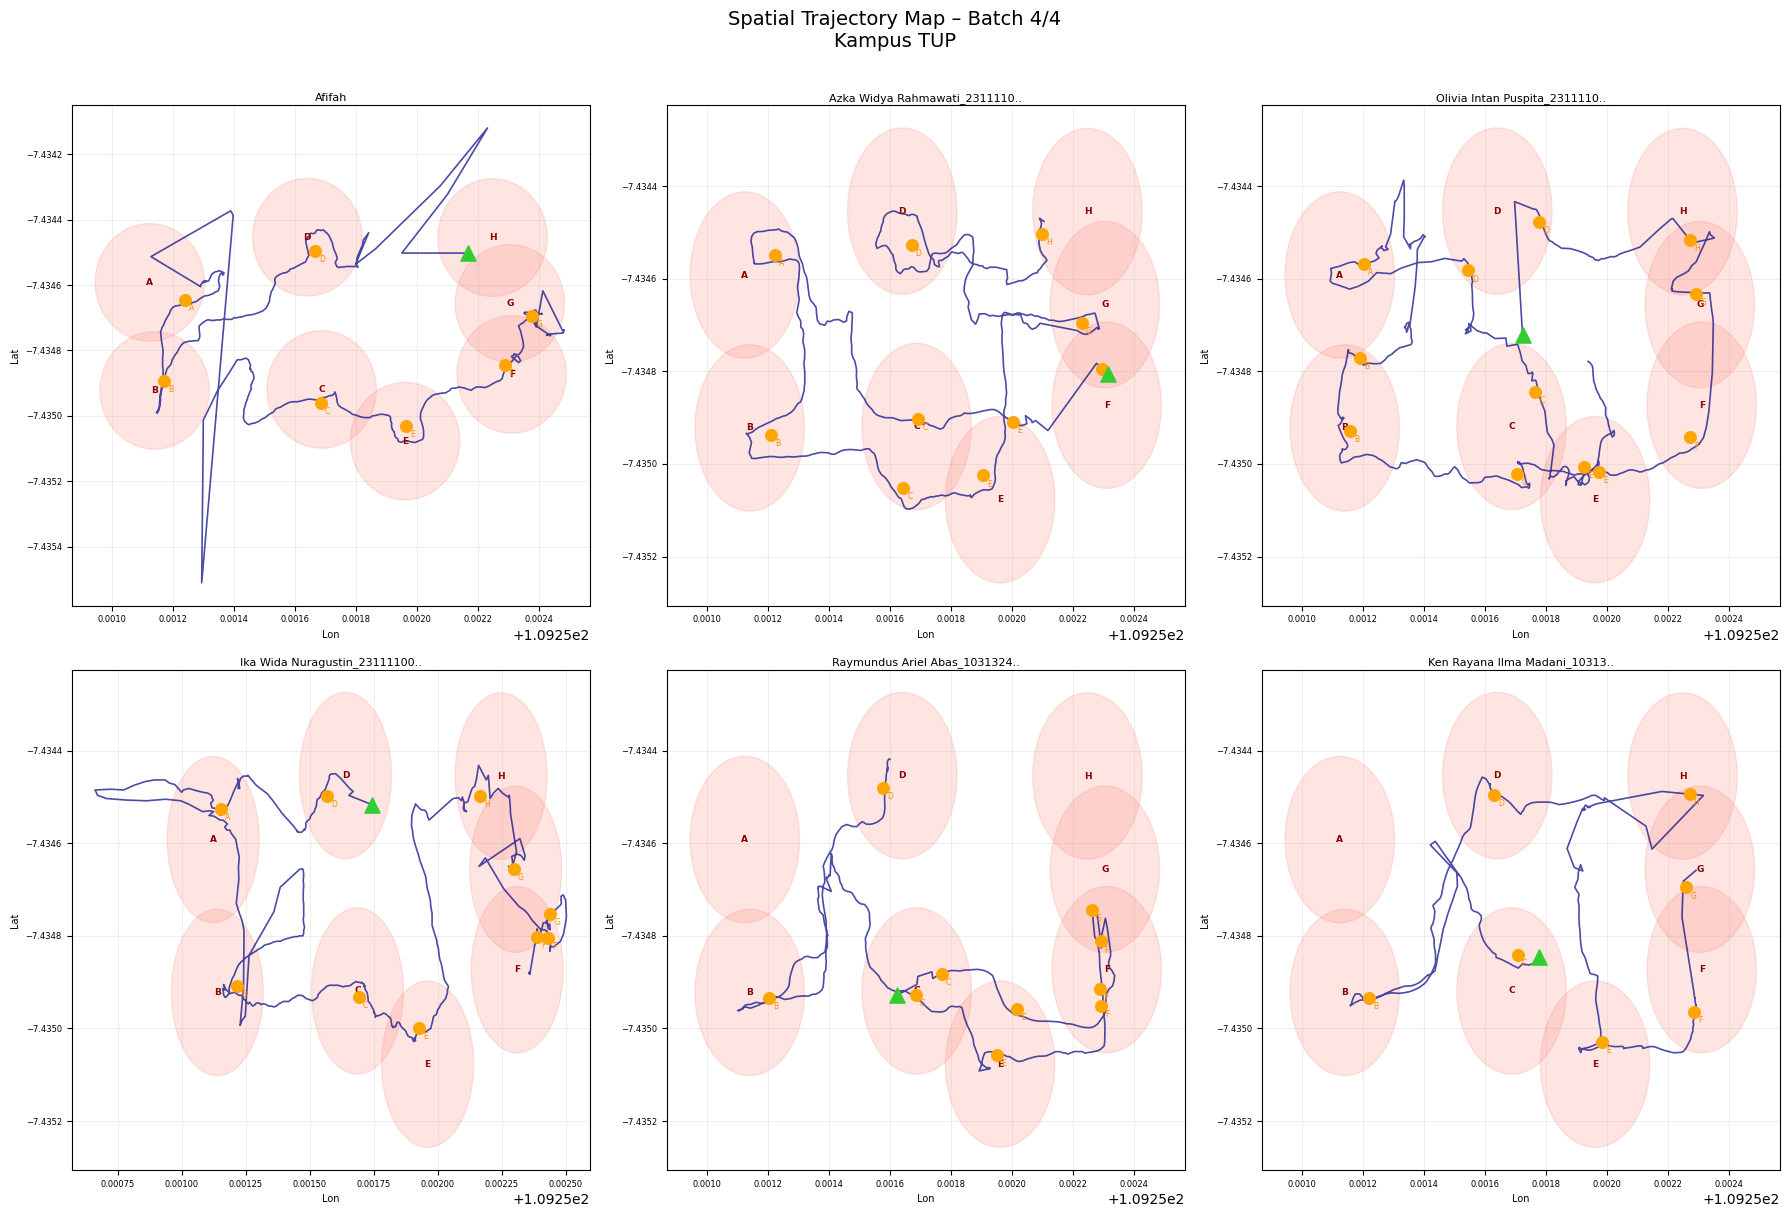

   ✅ Batch 4 disimpan ke /content/spatial_trajectory_batch_4.png


In [16]:
# ============================================================
# CELL 15: Visualisasi 5 – Spatial Trajectory Map (All Users)
# ============================================================
print("\n🗺️  VISUALISASI 5: Spatial Trajectory Map – Semua User")

if not df_all_merged.empty:
    import math as _math
    all_users  = df_all_merged['user_id'].unique()
    batch_size = 6
    n_batches  = _math.ceil(len(all_users) / batch_size)
    print(f"   {len(all_users)} user → {n_batches} batch")

    for b in range(n_batches):
        batch = all_users[b*batch_size : (b+1)*batch_size]
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for idx, uid in enumerate(batch):
            ax   = axes[idx]
            df_u = df_all_merged[df_all_merged['user_id'] == uid].sort_values('t_rel')
            v_u  = df_all_visits[df_all_visits['user_id']  == uid]

            ax.plot(df_u['lon'], df_u['lat'], '-', color='navy', lw=1.2, alpha=0.7)
            ax.scatter(df_u['lon'].iloc[0], df_u['lat'].iloc[0],
                       s=120, c='limegreen', marker='^', zorder=7, label='Start')

            deg_r = CP_RADIUS_M / 111320
            for cp_name, (clat, clon) in CHECKPOINTS.items():
                circle = plt.Circle((clon, clat), deg_r, color='salmon', alpha=0.2)
                ax.add_patch(circle)
                ckey = cp_name.split(':')[0].strip()
                ax.text(clon, clat, ckey, fontsize=6.5, ha='center', va='center',
                        color='darkred', fontweight='bold')

            if not v_u.empty:
                ax.scatter(v_u['lon_mean'], v_u['lat_mean'],
                           s=70, c='orange', zorder=6, marker='o', label='CP visited')
                for _, vrow in v_u.iterrows():
                    ckey = vrow['checkpoint'].split(':')[0].strip()
                    ax.annotate(ckey, (vrow['lon_mean'], vrow['lat_mean']),
                                textcoords='offset points', xytext=(3,-8),
                                fontsize=5.5, color='darkorange')

            uid_title = uid[:28] + '..' if len(uid) > 28 else uid
            ax.set_title(f'{uid_title}', fontsize=8, pad=3)
            ax.set_xlabel('Lon', fontsize=7)
            ax.set_ylabel('Lat', fontsize=7)
            ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.2)

        for i in range(len(batch), len(axes)):
            axes[i].set_visible(False)

        plt.suptitle(f'Spatial Trajectory Map – Batch {b+1}/{n_batches}\nKampus TUP',
                     fontsize=14, y=1.01)
        plt.tight_layout()
        fname_out = f'/content/spatial_trajectory_batch_{b+1}.png'
        plt.savefig(fname_out, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"   ✅ Batch {b+1} disimpan ke {fname_out}")



🤖 MODEL BERT: Prediksi Lokasi Berikutnya (FIXED VERSION)
------------------------------------------------------------
Pendekatan: BERT Sequence Classification
  • Input  = sequence checkpoint yang sudah dikunjungi
  • Output = checkpoint berikutnya (classification)
  • Proper train/test split + confusion matrix
------------------------------------------------------------

   Raw sequences         : 24
   Jumlah checkpoint     : 8
   Rata-rata panjang seq : 9.2
   Augmented samples     : 739
   Train samples         : 591
   Test samples          : 148
   Label distribution    : {np.int64(0): np.int64(38), np.int64(1): np.int64(76), np.int64(2): np.int64(130), np.int64(3): np.int64(95), np.int64(4): np.int64(97), np.int64(5): np.int64(117), np.int64(6): np.int64(126), np.int64(7): np.int64(60)}


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Tokens added          : 8

   Device: cpu


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialize

   Trainable params      : 37,628,936 / 109,494,536 (34.4%)

   Training 30 epochs...
   Epoch 05/30 | Loss: 2.0197 | Train Acc: 0.1861
   Epoch 10/30 | Loss: 1.9394 | Train Acc: 0.2183
   Epoch 15/30 | Loss: 1.8572 | Train Acc: 0.2640
   Epoch 20/30 | Loss: 1.8183 | Train Acc: 0.2690
   Epoch 25/30 | Loss: 1.7580 | Train Acc: 0.3198
   Epoch 30/30 | Loss: 1.7299 | Train Acc: 0.3350


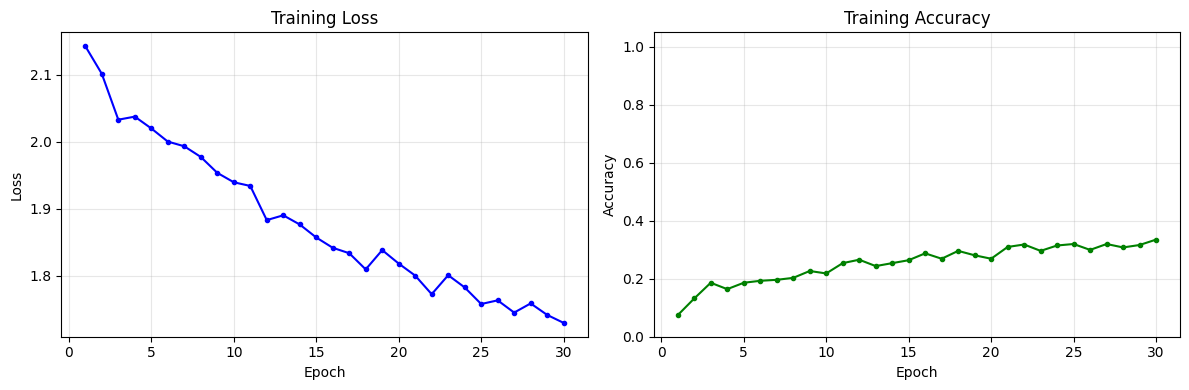


✅ Training selesai

📊 EVALUASI MODEL BERT
   Test Accuracy: 0.3243 (32.43%)

   Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         8
           B       0.64      0.47      0.54        15
           C       0.34      0.38      0.36        26
           D       0.24      0.53      0.33        19
           E       0.00      0.00      0.00        19
           F       0.11      0.04      0.06        24
           G       0.35      0.80      0.49        25
           H       0.00      0.00      0.00        12

    accuracy                           0.32       148
   macro avg       0.21      0.28      0.22       148
weighted avg       0.23      0.32      0.25       148



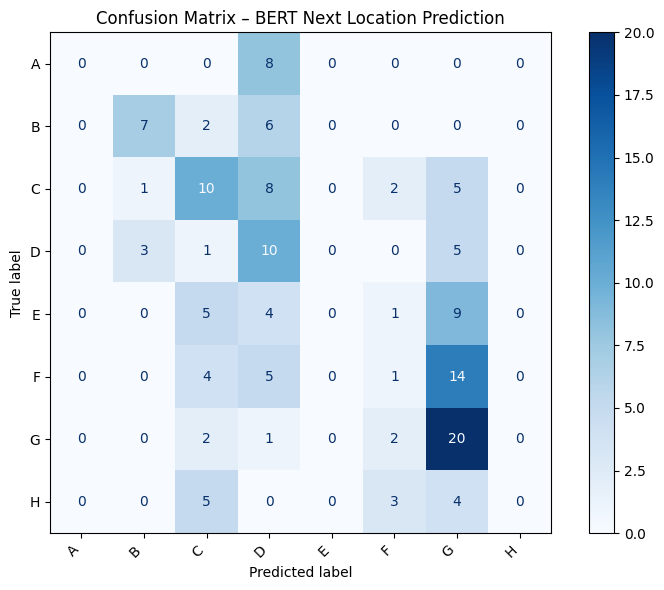

✅ Confusion matrix disimpan: /content/bert_confusion_matrix.png

   📍 Contoh Prediksi Next Location (BERT):
------------------------------------------------------------
   Context : B → D → H → G
   Top-3   : G (0.465) | F (0.299) | E (0.073)
   Aktual  : G  ✅

   Context : B → C → E
   Top-3   : D (0.252) | B (0.187) | C (0.141)
   Aktual  : F  ❌

   Context : B → C → E → F → G
   Top-3   : G (0.329) | F (0.287) | C (0.128)
   Aktual  : H  ❌

   Context : E → C → E
   Top-3   : D (0.216) | B (0.210) | C (0.165)
   Aktual  : F  ❌

   Context : C → D → H
   Top-3   : G (0.459) | F (0.289) | E (0.086)
   Aktual  : F  ❌

📋 RINGKASAN MODEL BERT
   Arsitektur        : BertForSequenceClassification
   Pretrained        : bert-base-uncased
   Jumlah kelas      : 8
   Total samples     : 739
   Train / Test      : 591 / 148
   Epochs            : 30
   Final Train Loss  : 1.7299
   Final Train Acc   : 0.3350
   Test Accuracy     : 0.3243


In [17]:
# ============================================================
# CELL 16: Model BERT – Next Location Prediction (FIXED)
# ============================================================
# PERBAIKAN UTAMA:
# 1. Arsitektur: BertForSequenceClassification (bukan MLM)
#    → Lebih tepat untuk next-location prediction (unidirectional task)
# 2. Data Augmentation: Sliding window + reverse sequences
#    → Mengatasi masalah dataset kecil
# 3. Proper Train/Test Split (80/20 stratified)
# 4. Custom token BENAR-BENAR single token (prefix ## dihindari)
# 5. Confusion Matrix + Classification Report + Accuracy
# 6. Multiple random seeds untuk reproducibility check
# ============================================================

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, BertConfig
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)
import numpy as np
import random

print("\n🤖 MODEL BERT: Prediksi Lokasi Berikutnya (FIXED VERSION)")
print("-"*60)
print("Pendekatan: BERT Sequence Classification")
print("  • Input  = sequence checkpoint yang sudah dikunjungi")
print("  • Output = checkpoint berikutnya (classification)")
print("  • Proper train/test split + confusion matrix")
print("-"*60)

# ── A. Vocabulary CP ──
cp_list   = list(CHECKPOINTS.keys())
n_classes = len(cp_list)
cp_to_idx = {cp: i for i, cp in enumerate(cp_list)}
idx_to_cp = {i: cp for cp, i in cp_to_idx.items()}

# Token khusus untuk setiap CP – gunakan format yang jelas
# Prefix [CP_X] agar tokenizer tidak men-split
cp_tokens = [f'[CP_{i}]' for i in range(n_classes)]
cp_to_token = {cp: cp_tokens[i] for i, cp in enumerate(cp_list)}
token_to_cp = {v: k for k, v in cp_to_token.items()}

def seq_to_text(seq):
    """Convert sequence of checkpoint names to token string."""
    return ' '.join([cp_to_token.get(s, '[UNK]') for s in seq if s in cp_to_token])

# ── B. Build Training Data ──
# Gunakan df_all_visits yang sudah bebas duplikasi
raw_sequences = []
for uid in df_all_visits['user_id'].unique():
    seq = df_all_visits[df_all_visits['user_id'] == uid]['checkpoint'].tolist()
    if len(seq) >= 3:
        raw_sequences.append(seq)

print(f"\n   Raw sequences         : {len(raw_sequences)}")
print(f"   Jumlah checkpoint     : {n_classes}")
print(f"   Rata-rata panjang seq : {np.mean([len(s) for s in raw_sequences]):.1f}")

# ── Data Augmentation: Sliding Window ──
# Untuk setiap sequence [A, B, C, D, E], buat:
#   context=[A,B] → target=C
#   context=[A,B,C] → target=D
#   context=[A,B,C,D] → target=E
#   context=[B,C] → target=D  (shifted window)
#   context=[B,C,D] → target=E

samples_X = []  # list of context sequences (as text)
samples_y = []  # list of target class indices

for seq in raw_sequences:
    # Original sliding window
    for start in range(len(seq)):
        for end in range(start + 2, len(seq)):
            context = seq[start:end]
            target  = seq[end]
            samples_X.append(seq_to_text(context))
            samples_y.append(cp_to_idx[target])

print(f"   Augmented samples     : {len(samples_X)}")

if len(samples_X) < 10:
    print("\n⚠️  Dataset terlalu kecil bahkan setelah augmentasi.")
    print("    Pastikan df_all_visits memiliki cukup data.")
    print("    Menggunakan Markov Chain sebagai fallback...\n")

    trans_freq = df_all_transitions.groupby(['from_cp','to_cp']).size().reset_index(name='count')
    def predict_markov(current_cp, top_k=3):
        cands = trans_freq[trans_freq['from_cp'] == current_cp].copy()
        if cands.empty: return []
        cands['prob'] = cands['count'] / cands['count'].sum()
        return cands.nlargest(top_k, 'count')[['to_cp','prob']].values.tolist()

    print("   📍 Prediksi Next Location (Markov Chain):")
    for cp in cp_list[:5]:
        preds = predict_markov(cp)
        if preds:
            print(f"   Dari {cp.split(':')[0]:<10} → "
                  + " | ".join([f"{p[0].split(':')[0]} ({p[1]:.1%})" for p in preds]))

else:
    # ── C. Train/Test Split ──
    X_train, X_test, y_train, y_test = train_test_split(
        samples_X, samples_y, test_size=0.2, random_state=42, stratify=samples_y
    )
    print(f"   Train samples         : {len(X_train)}")
    print(f"   Test samples          : {len(X_test)}")
    print(f"   Label distribution    : {dict(zip(*np.unique(samples_y, return_counts=True)))}")

    # ── D. Tokenizer & Dataset ──
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    num_added = tokenizer.add_tokens(cp_tokens)
    print(f"   Tokens added          : {num_added}")

    class CPClassificationDataset(Dataset):
        def __init__(self, texts, labels, tok, max_len=64):
            self.samples = []
            for text, label in zip(texts, labels):
                enc = tok(text, max_length=max_len, padding='max_length',
                          truncation=True, return_tensors='pt')
                self.samples.append({
                    'input_ids':      enc['input_ids'].squeeze(0),
                    'attention_mask': enc['attention_mask'].squeeze(0),
                    'label':          torch.tensor(label, dtype=torch.long)
                })
        def __len__(self): return len(self.samples)
        def __getitem__(self, i): return self.samples[i]

    train_dataset = CPClassificationDataset(X_train, y_train, tokenizer)
    test_dataset  = CPClassificationDataset(X_test, y_test, tokenizer)

    # ── E. Model Setup ──
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n   Device: {device}")

    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=n_classes
    )
    model.resize_token_embeddings(len(tokenizer))

    # Freeze BERT layers kecuali classifier + last 2 encoder layers
    # Ini mencegah catastrophic forgetting pada data kecil
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True
        elif 'encoder.layer.11' in name or 'encoder.layer.10' in name:
            param.requires_grad = True
        elif 'embeddings.word_embeddings' in name:
            # Harus trainable agar token baru bisa belajar
            param.requires_grad = True
        else:
            param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"   Trainable params      : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

    # ── F. Training ──
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=2e-5, weight_decay=0.01
    )
    # Learning rate scheduler (warm-up lalu decay)
    from transformers import get_linear_schedule_with_warmup
    N_EPOCH = 30
    total_steps = len(train_loader) * N_EPOCH
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    loss_fn = nn.CrossEntropyLoss()
    train_losses = []
    train_accs   = []

    print(f"\n   Training {N_EPOCH} epochs...")
    model.train()
    for epoch in range(N_EPOCH):
        total_loss = 0
        correct = 0
        total   = 0
        for batch in train_loader:
            ids  = batch['input_ids'].to(device)
            att  = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=att, labels=lbl)
            loss = outputs.loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=-1)
            correct += (preds == lbl).sum().item()
            total   += lbl.size(0)

        avg_loss = total_loss / len(train_loader)
        avg_acc  = correct / total
        train_losses.append(avg_loss)
        train_accs.append(avg_acc)

        if (epoch + 1) % 5 == 0:
            print(f"   Epoch {epoch+1:02d}/{N_EPOCH} | "
                  f"Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f}")

    # ── G. Plot Training Curve ──
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, N_EPOCH+1), train_losses, 'b-o', markersize=3)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss'); ax1.grid(True, alpha=0.3)

    ax2.plot(range(1, N_EPOCH+1), train_accs, 'g-o', markersize=3)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy'); ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])

    plt.tight_layout()
    plt.savefig('/content/bert_training_curves.png', dpi=120)
    plt.show()
    print("\n Training selesai")

    # ── H. Evaluation on Test Set ──
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            ids  = batch['input_ids'].to(device)
            att  = batch['attention_mask'].to(device)
            lbl  = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=att)
            preds = torch.argmax(outputs.logits, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    test_acc = accuracy_score(all_labels, all_preds)
    print(f"\n EVALUASI MODEL BERT")
    print("="*60)
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

    # ── Classification Report ──
    # Hanya tampilkan label yang benar-benar muncul di test set
    present_labels = sorted(set(all_labels) | set(all_preds))
    target_names = [idx_to_cp[i].split(':')[0].strip() for i in present_labels]

    print(f"\n   Classification Report:")
    report = classification_report(
        all_labels, all_preds,
        labels=present_labels,
        target_names=target_names,
        zero_division=0
    )
    print(report)

    # ── Confusion Matrix ──
    cm = confusion_matrix(all_labels, all_preds, labels=present_labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title('Confusion Matrix – BERT Next Location Prediction')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('/content/bert_confusion_matrix.png', dpi=120)
    plt.show()
    print(" Confusion matrix disimpan: /content/bert_confusion_matrix.png")

    # ── I. Contoh Prediksi ──
    print(f"\n   📍 Contoh Prediksi Next Location (BERT):")
    print("-"*60)
    sample_indices = random.sample(range(len(X_test)), min(5, len(X_test)))
    for si in sample_indices:
        text = X_test[si]
        true_label = y_test[si]

        enc = tokenizer(text, return_tensors='pt', max_length=64,
                        padding='max_length', truncation=True)
        ids = enc['input_ids'].to(device)
        att = enc['attention_mask'].to(device)

        with torch.no_grad():
            out = model(input_ids=ids, attention_mask=att)

        probs = torch.softmax(out.logits[0], dim=-1)
        top3  = torch.topk(probs, min(3, n_classes))

        # Decode context
        ctx_tokens = text.split()
        ctx_cps = [token_to_cp.get(t, t).split(':')[0].strip() for t in ctx_tokens]

        pred_idx = top3.indices[0].item()
        pred_cp  = idx_to_cp[pred_idx].split(':')[0].strip()
        true_cp  = idx_to_cp[true_label].split(':')[0].strip()

        print(f"   Context : {' → '.join(ctx_cps)}")
        print(f"   Top-3   : ", end="")
        for rank in range(len(top3.indices)):
            ci = top3.indices[rank].item()
            cp = idx_to_cp[ci].split(':')[0].strip()
            pr = top3.values[rank].item()
            print(f"{cp} ({pr:.3f})", end=" | " if rank < len(top3.indices)-1 else "")
        print()
        print(f"   Aktual  : {true_cp}  {'✅' if pred_idx == true_label else '❌'}")
        print()

    # ── J. Ringkasan ──
    print("="*60)
    print(f" RINGKASAN MODEL BERT")
    print(f"   Arsitektur        : BertForSequenceClassification")
    print(f"   Pretrained        : bert-base-uncased")
    print(f"   Jumlah kelas      : {n_classes}")
    print(f"   Total samples     : {len(samples_X)}")
    print(f"   Train / Test      : {len(X_train)} / {len(X_test)}")
    print(f"   Epochs            : {N_EPOCH}")
    print(f"   Final Train Loss  : {train_losses[-1]:.4f}")
    print(f"   Final Train Acc   : {train_accs[-1]:.4f}")
    print(f"   Test Accuracy     : {test_acc:.4f}")
    print("="*60)


In [18]:
# ============================================================
# CELL 17: Statistik Akhir & Ringkasan Output
# ============================================================
print("\n STATISTIK AKHIR")
print("="*65)

if not df_all_transitions.empty:
    print("\n Statistik Transition Path:")
    print(df_all_transitions[['transition_time','distance_m','speed_est_ms']]
          .describe().round(3).to_string())

if not df_all_visits.empty:
    print("\n Frekuensi Kunjungan per Checkpoint:")
    print(df_all_visits['checkpoint'].value_counts().to_string())

    print("\n Rata-rata Durasi Berhenti per Checkpoint (detik):")
    print(df_all_visits.groupby('checkpoint')['duration_s']
          .mean().round(2).sort_values(ascending=False).to_string())

    print("\n Jumlah Visit Unik per User (setelah deduplikasi):")
    print(df_all_visits.groupby('user_id')['checkpoint']
          .count().sort_values(ascending=False).head(15).to_string())

print("\n" + "="*65)
print(" SEMUA PROSES SELESAI!")
print("\nFile output yang dihasilkan:")
files_out = [
    '/content/summary_transition_path.csv',
    '/content/output_mobility_event.csv',
    '/content/heatmap_mobilitas.png',
    '/content/transition_graph.png',
    '/content/sankey_diagram.html',
    '/content/floor_plan_route.html',
    '/content/spatial_trajectory_batch_*.png',
    '/content/bert_training_loss.png',
]
for fo in files_out:
    print(f"  - {fo}")



📊 STATISTIK AKHIR

🔁 Statistik Transition Path:
       transition_time  distance_m  speed_est_ms
count          196.000     196.000       196.000
mean            27.730      38.618         7.647
std             32.902      17.722        10.070
min              0.985       5.760         0.104
25%              2.000      25.754         1.127
50%             19.001      36.615         2.421
75%             41.003      51.323         9.576
max            198.000     118.415        33.868

📍 Frekuensi Kunjungan per Checkpoint:
checkpoint
C: Rektorat            40
E: Parkiran Terbuka    34
F: DC                  33
G: Iot                 31
B: Parkir Luar DSP     27
D: Climbing            26
H: TT                  17
A: DSP                 12

⏱️  Rata-rata Durasi Berhenti per Checkpoint (detik):
checkpoint
D: Climbing            58.60
C: Rektorat            47.03
B: Parkir Luar DSP     44.44
E: Parkiran Terbuka    42.26
G: Iot                 39.04
F: DC                  38.13
H: TT       